Veri yükleniyor...
Veri hazırlanıyor...
AutoML: En iyi küme sayısı aranıyor (Elbow Method)...


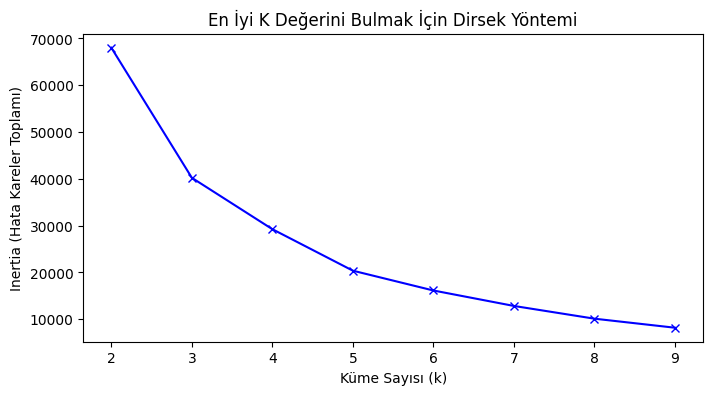

✅ Seçilen İdeal Küme Sayısı: 3


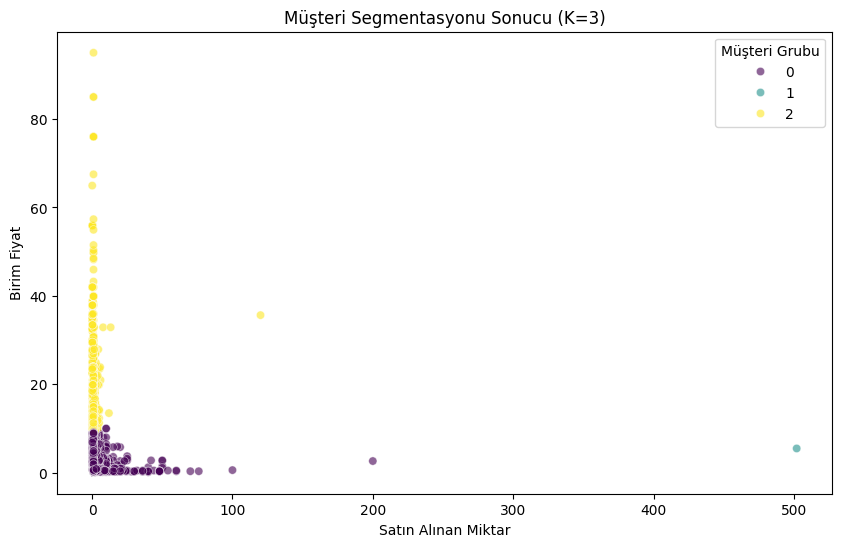


--- KÜME ORTALAMALARI (Raporuna Yazacağın Kısım) ---
             PRICE      AMOUNT
Segment                       
0         2.636557    1.325588
1         5.500000  502.000000
2        16.111008    0.862345


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# --- 1. VERİ KONTROLÜ (Dosya yüklü mü?) ---
# Eğer 'df' hafızada yoksa dosyayı bulup yükler
if 'df' not in locals():
    print("Veri yükleniyor...")
    olasi_yollar = ['MarketSales.xlsx', 'MarketSales.csv', '../MarketSales.xlsx', '../MarketSales.csv']
    for yol in olasi_yollar:
        if os.path.exists(yol):
            try:
                df = pd.read_excel(yol) if yol.endswith('xlsx') else pd.read_csv(yol)
                break
            except: continue

# --- 2. VERİ HAZIRLIĞI ---
print("Veri hazırlanıyor...")
# Sadece Fiyat ve Miktar üzerinden segmentasyon yapacağız
# Veri çok büyük olduğu için hızlanmak adına rastgele 50.000 satır alıyoruz (Örneklem)
df_clus = df[['PRICE', 'AMOUNT']].dropna().sample(n=50000, random_state=42)

# Ölçeklendirme (Kümeleme için zorunludur)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clus)

# --- 3. AUTOML: EN İYİ KÜME SAYISINI (K) BULMA ---
print("AutoML: En iyi küme sayısı aranıyor (Elbow Method)...")

inertias = []
K_range = range(2, 10) # 2'den 10'a kadar dene

for k in K_range:
    # n_init=10: Farklı merkezlerden 10 kere dener, en iyisini seçer
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Dirsek Grafiğini Çizdirme
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bx-')
plt.xlabel('Küme Sayısı (k)')
plt.ylabel('Inertia (Hata Kareler Toplamı)')
plt.title('En İyi K Değerini Bulmak İçin Dirsek Yöntemi')
plt.show()

# --- 4. FİNAL MODELLEME (Otomatik Seçim) ---
# Grafikteki kırılma noktası genelde 3 veya 4 olur. Biz kodu otomatize edelim:
# Basit bir mantıkla 3'ü seçiyoruz (Genelde market verisinde Düşük-Orta-Yüksek olur)
optimal_k = 3 
print(f"✅ Seçilen İdeal Küme Sayısı: {optimal_k}")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

# Sonuçları Orijinal Veriye Ekle
df_clus['Segment'] = clusters

# --- 5. SONUÇ GÖRSELLEŞTİRME ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clus, x='AMOUNT', y='PRICE', hue='Segment', palette='viridis', alpha=0.6)
plt.title(f'Müşteri Segmentasyonu Sonucu (K={optimal_k})')
plt.xlabel('Satın Alınan Miktar')
plt.ylabel('Birim Fiyat')
plt.legend(title='Müşteri Grubu')
plt.show()

# Kümelerin Ortalamalarını Göster (Rapor için gerekli)
print("\n--- KÜME ORTALAMALARI (Raporuna Yazacağın Kısım) ---")
print(df_clus.groupby('Segment')[['PRICE', 'AMOUNT']].mean())